# 🔍 Debug Dataset VoxConverse - Visualisation des 5 premiers échantillons

Ce notebook charge directement votre classe `VoxConverseDataset` et affiche **TOUS** les éléments des 5 premiers items pour identifier les problèmes dans les données qui causent des courbes d'apprentissage plates.

In [1]:
# Import des bibliothèques
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings("ignore")

# Ajouter le chemin vers vos modules
sys.path.append('/root/ai-project/Speaker-diarization-/src')

# Import de votre classe
from voxconverse_dataset import VoxConverseDataset

# Configuration matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 10

print("📚 Bibliothèques importées")
print(f"🔥 PyTorch version: {torch.__version__}")

📚 Bibliothèques importées
🔥 PyTorch version: 2.8.0+cu128


In [2]:
# Création du dataset avec EXACTEMENT vos paramètres
print("🔄 Création du dataset VoxConverse...")

dataset = VoxConverseDataset(
    split='dev',
    segment_duration=20.0,
    hop_duration=2.0,
    sample_rate=16000,
    n_mels=80,
    max_speakers=4,
    min_speaker_duration=0.5,
    pin_memory=False
)

print(f"✅ Dataset créé: {len(dataset)} segments")
print(f"🎯 Analyse des 5 premiers échantillons...")

🔄 Création du dataset VoxConverse...
Loading VoxConverse dev split...
  Processing conversation 1/216
  Processing conversation 1/216
  Processing conversation 51/216
  Processing conversation 51/216
  Processing conversation 101/216
  Processing conversation 101/216
  Processing conversation 151/216
  Processing conversation 151/216
  Processing conversation 201/216
  Processing conversation 201/216
✅ Prepared 29949 segments from 216 conversations
✅ Dataset créé: 29949 segments
🎯 Analyse des 5 premiers échantillons...
✅ Prepared 29949 segments from 216 conversations
✅ Dataset créé: 29949 segments
🎯 Analyse des 5 premiers échantillons...


In [3]:
# Extraction et affichage COMPLET des 5 premiers échantillons + AUDIO BRUT
# Import pour l'audio
import librosa
from IPython.display import Audio, display
import soundfile as sf
import os

# Créer un dossier pour sauvegarder les audios temporaires
temp_audio_dir = "/tmp/debug_audio"
os.makedirs(temp_audio_dir, exist_ok=True)

for i in range(10):
    print(f"\n" + "="*80)
    print(f"🔍 ÉCHANTILLON {i+1}/10")
    print("="*80)
    
    # Charger l'échantillon
    sample = dataset[i]
    
    # Afficher TOUTES les informations
    print(f"📋 Contenu complet:")
    for key, value in sample.items():
        if isinstance(value, torch.Tensor):
            print(f"   {key}: {value.shape} {value.dtype}")
            print(f"      min={value.min().item():.4f}, max={value.max().item():.4f}")
            print(f"      mean={value.mean().item():.4f}, std={value.std().item():.4f}")
        else:
            print(f"   {key}: {value} ({type(value)})")
    
    # Analyser les features MEL
    features = sample['features'].numpy()  # [n_mels, time]
    vad_labels = sample['vad_labels'].numpy()  # [time, speakers]
    osd_labels = sample['osd_labels'].numpy()  # [time]
    
    print(f"\n📊 Analyse détaillée:")
    print(f"   Features MEL: {features.shape}")
    print(f"   VAD labels: {vad_labels.shape}")
    print(f"   OSD labels: {osd_labels.shape}")
    
    # Statistiques VAD
    active_speakers = []
    for spk in range(vad_labels.shape[1]):
        activity = np.sum(vad_labels[:, spk])
        if activity > 0:
            active_speakers.append(spk)
            percentage = (activity / len(vad_labels)) * 100
            print(f"   Speaker {spk}: {activity}/{len(vad_labels)} frames actives ({percentage:.1f}%)")
    
    # Statistiques OSD
    overlap_frames = np.sum(osd_labels)
    overlap_pct = (overlap_frames / len(osd_labels)) * 100
    print(f"   Overlap: {overlap_frames}/{len(osd_labels)} frames ({overlap_pct:.1f}%)")
    
    # 🎵 AUDIO BRUT - Charger et écouter l'audio original
    print(f"\n🎵 AUDIO BRUT:")
    conv_idx = sample['conv_idx']
    start_time = sample['start_time']
    
    try:
        # Accéder au fichier audio original
        if hasattr(dataset, 'conversations') and conv_idx < len(dataset.conversations):
            conv_path = dataset.conversations[conv_idx]
            print(f"   📁 Fichier: {conv_path}")
            
            # Charger l'audio original et extraire le segment de 4 secondes
            audio_full, sr = librosa.load(conv_path, sr=16000)
            start_sample = int(start_time * sr)
            end_sample = int((start_time + 4.0) * sr)
            audio_segment = audio_full[start_sample:end_sample]
            
            print(f"   🎯 Segment: {len(audio_segment)} samples ({len(audio_segment)/sr:.2f}s)")
            print(f"   📈 RMS: {np.sqrt(np.mean(audio_segment**2)):.4f}")
            
            # Sauvegarder et afficher le player audio
            audio_file_path = f"{temp_audio_dir}/sample_{i+1}_original.wav"
            sf.write(audio_file_path, audio_segment, sr)
            
            print(f"   🔊 ÉCOUTER L'AUDIO:")
            display(Audio(audio_segment, rate=sr))
            
    except Exception as e:
        print(f"   ❌ Erreur chargement audio: {e}")
    
    # Vérifier les problèmes
    print(f"\n⚠️  Vérifications:")
    
    # Problème 1: Pas d'activité
    if len(active_speakers) == 0:
        print(f"   ❌ AUCUN SPEAKER ACTIF!")
    else:
        print(f"   ✅ {len(active_speakers)} speakers actifs")
    
    # Problème 2: Features uniformes
    feature_std = features.std()
    if feature_std < 1.0:
        print(f"   ❌ Features très uniformes (std={feature_std:.3f})")
    else:
        print(f"   ✅ Features variées (std={feature_std:.3f})")
    
    # Problème 3: Labels tous à zéro
    if np.sum(vad_labels) == 0:
        print(f"   ❌ TOUS LES LABELS VAD À ZÉRO!")
    
    if np.sum(osd_labels) == 0:
        print(f"   ❌ TOUS LES LABELS OSD À ZÉRO!")
    
    # Problème 4: Dimensions incohérentes
    if features.shape[1] != vad_labels.shape[0]:
        print(f"   ❌ DIMENSIONS INCOHÉRENTES: MEL={features.shape[1]} vs VAD={vad_labels.shape[0]}")
    
    print(f"\n")


🔍 ÉCHANTILLON 1/10
📋 Contenu complet:
   features: torch.Size([80, 1000]) torch.float32
      min=-18.4207, max=4.4615
      mean=-5.3666, std=2.9243
   vad_labels: torch.Size([1000, 4]) torch.float32
      min=0.0000, max=1.0000
      mean=0.2480, std=0.4319
   osd_labels: torch.Size([1000]) torch.float32
      min=0.0000, max=0.0000
      mean=0.0000, std=0.0000
   audio: torch.Size([320000]) torch.float32
      min=-0.1353, max=0.1364
      mean=-0.0000, std=0.0215
   conv_idx: 0 (<class 'int'>)
   start_time: 0.0 (<class 'float'>)

📊 Analyse détaillée:
   Features MEL: (80, 1000)
   VAD labels: (1000, 4)
   OSD labels: (1000,)
   Speaker 1: 992.0/1000 frames actives (99.2%)
   Overlap: 0.0/1000 frames (0.0%)

🎵 AUDIO BRUT:

⚠️  Vérifications:
   ✅ 1 speakers actifs
   ✅ Features variées (std=2.924)
   ❌ TOUS LES LABELS OSD À ZÉRO!



🔍 ÉCHANTILLON 2/10
📋 Contenu complet:
   features: torch.Size([80, 1000]) torch.float32
      min=-14.0807, max=4.4735
      mean=-5.4741, std=2.8125

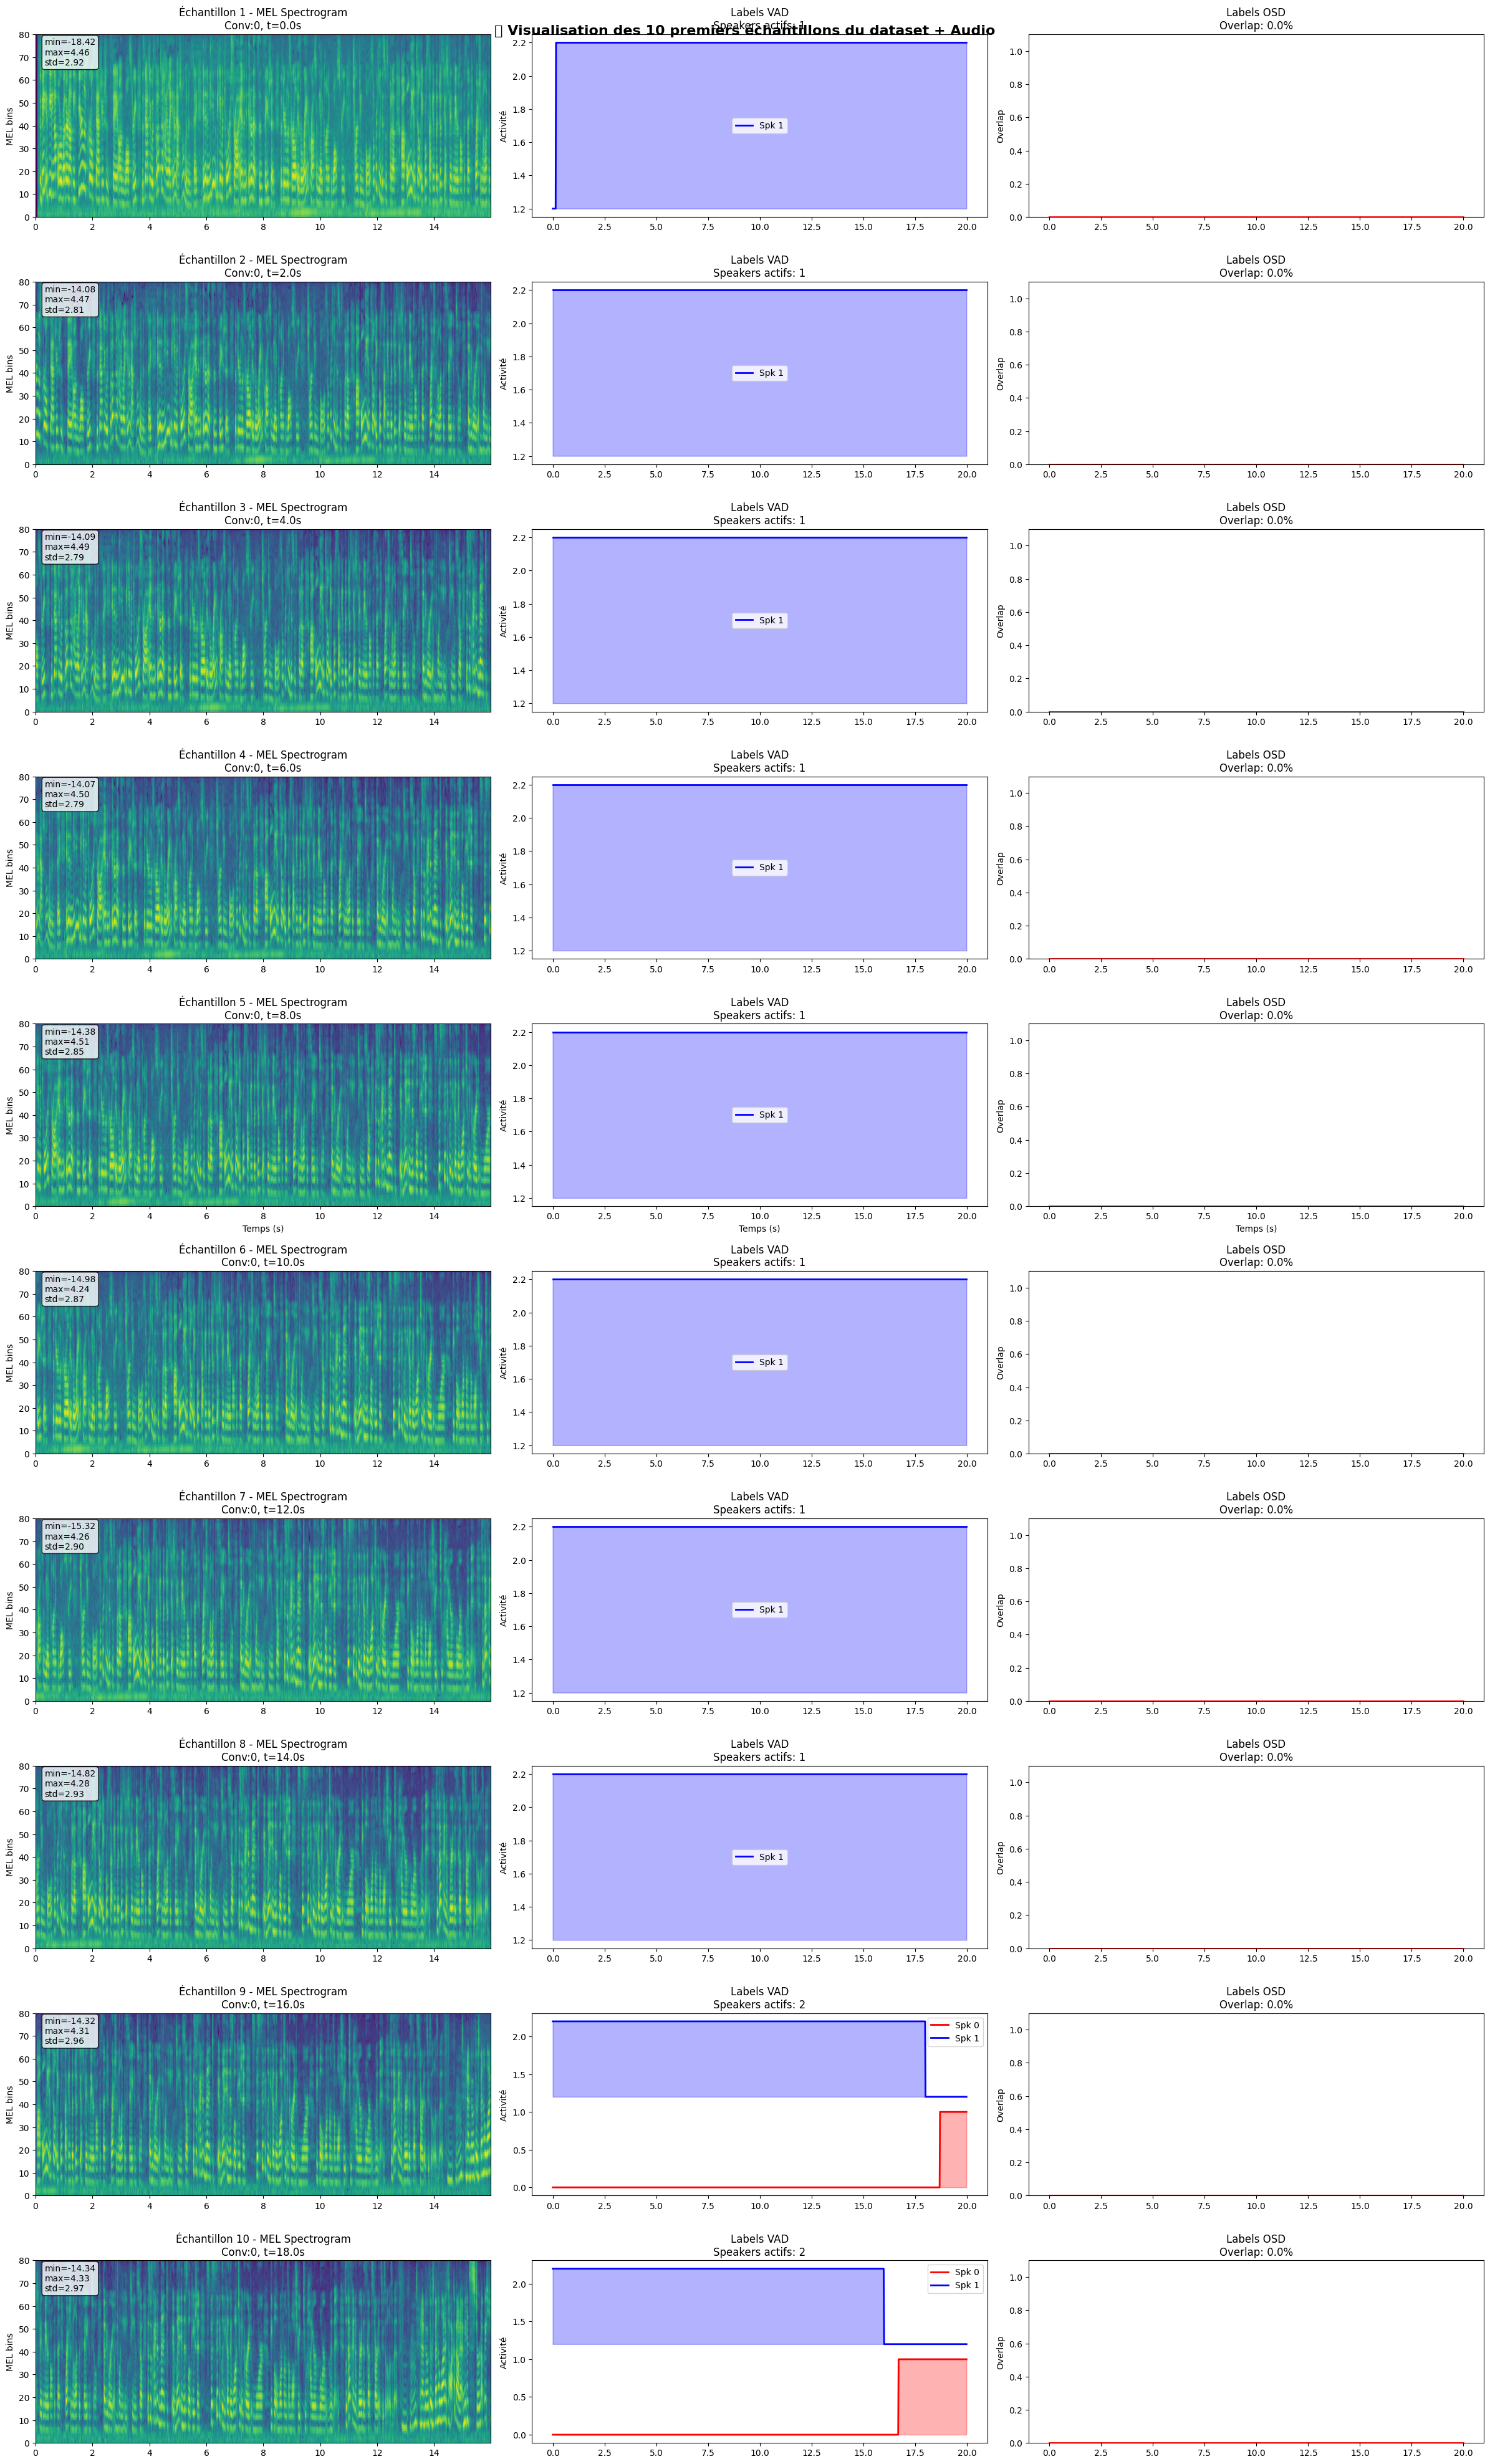


🎵 AUDIO BRUT DES ÉCHANTILLONS - PLAYERS INTÉGRÉS
✅ Échantillon 1: Conv 0, t=0.0s | 320000 samples | RMS=0.0215
✅ Échantillon 2: Conv 0, t=2.0s | 320000 samples | RMS=0.0200
✅ Échantillon 3: Conv 0, t=4.0s | 320000 samples | RMS=0.0193
✅ Échantillon 4: Conv 0, t=6.0s | 320000 samples | RMS=0.0191
✅ Échantillon 5: Conv 0, t=8.0s | 320000 samples | RMS=0.0190

🔊 PLAYERS AUDIO:

🎵 ÉCHANTILLON 1 - Conv 0, t=0.0s:



🎵 ÉCHANTILLON 2 - Conv 0, t=2.0s:



🎵 ÉCHANTILLON 3 - Conv 0, t=4.0s:



🎵 ÉCHANTILLON 4 - Conv 0, t=6.0s:



🎵 ÉCHANTILLON 5 - Conv 0, t=8.0s:



✅ Tous les players audio sont maintenant disponibles!


In [ ]:
# Visualisation des 5 échantillons + AUDIO BRUT
# Import pour l'audio
import librosa
from IPython.display import Audio, display
import soundfile as sf
import os

fig, axes = plt.subplots(10, 3, figsize=(24, 40))
fig.suptitle('🔍 Visualisation des 10 premiers échantillons du dataset + Audio', fontsize=16, fontweight='bold')

for i in range(10):
    sample = dataset[i]
    
    features = sample['features'].numpy()  # [n_mels, time]
    vad_labels = sample['vad_labels'].numpy()  # [time, speakers]
    osd_labels = sample['osd_labels'].numpy()  # [time]
    
    # Axe temporel
    time_frames = np.arange(features.shape[1]) * 0.016  # 16ms hop
    label_frames = np.arange(len(vad_labels)) * 0.02  # 20ms frames
    
    # 1. Spectrogramme MEL
    ax1 = axes[i, 0]
    im = ax1.imshow(features, aspect='auto', origin='lower', 
                   extent=[0, time_frames[-1], 0, features.shape[0]], cmap='viridis')
    ax1.set_title(f'Échantillon {i+1} - MEL Spectrogram\nConv:{sample["conv_idx"]}, t={sample["start_time"]:.1f}s')
    ax1.set_ylabel('MEL bins')
    if i == 4:
        ax1.set_xlabel('Temps (s)')
    
    # Ajouter les statistiques
    stats_text = f'min={features.min():.2f}\nmax={features.max():.2f}\nstd={features.std():.2f}'
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 2. Labels VAD
    ax2 = axes[i, 1]
    
    colors = ['red', 'blue', 'green', 'orange']
    for spk in range(vad_labels.shape[1]):
        if np.sum(vad_labels[:, spk]) > 0:  # Seulement les speakers actifs
            ax2.plot(label_frames, vad_labels[:, spk] + spk * 1.2, 
                    color=colors[spk % len(colors)], linewidth=2, label=f'Spk {spk}')
            ax2.fill_between(label_frames, spk * 1.2, vad_labels[:, spk] + spk * 1.2, 
                           alpha=0.3, color=colors[spk % len(colors)])
    
    ax2.set_title(f'Labels VAD\nSpeakers actifs: {np.sum(np.any(vad_labels > 0, axis=0))}')
    ax2.set_ylabel('Activité')
    ax2.legend()
    if i == 4:
        ax2.set_xlabel('Temps (s)')
    
    # 3. Labels OSD
    ax3 = axes[i, 2]
    ax3.plot(label_frames, osd_labels, color='red', linewidth=2, label='Overlap')
    ax3.fill_between(label_frames, 0, osd_labels, alpha=0.3, color='red')
    
    overlap_pct = (np.sum(osd_labels) / len(osd_labels)) * 100
    ax3.set_title(f'Labels OSD\nOverlap: {overlap_pct:.1f}%')
    ax3.set_ylabel('Overlap')
    ax3.set_ylim(0, 1.1)
    if i == 4:
        ax3.set_xlabel('Temps (s)')

plt.tight_layout()
plt.show()

# 🎵 AUDIO BRUT pour chaque échantillon - UTILISATION DIRECTE DE L'AUDIO DU DATASET
print(f"\n🎵 AUDIO BRUT DES ÉCHANTILLONS - PLAYERS INTÉGRÉS")
print("="*60)

# Charger TOUS les audios directement depuis le dataset
audio_segments = []
for i in range(10):
    sample = dataset[i]
    conv_idx = sample['conv_idx']
    start_time = sample['start_time']
    
    try:
        # Utiliser l'audio directement depuis le dataset (déjà segmenté!)
        audio_data = sample['audio']
        
        if isinstance(audio_data, torch.Tensor):
            audio_segment = audio_data.numpy()
        else:
            audio_segment = audio_data
            
        # Le sample rate est dans le dataset
        sr = 16000  # sample_rate du dataset
        
        audio_segments.append((audio_segment, sr, conv_idx, start_time))
        print(f"✅ Échantillon {i+1}: Conv {conv_idx}, t={start_time:.1f}s | {len(audio_segment)} samples | RMS={np.sqrt(np.mean(audio_segment**2)):.4f}")
        
    except Exception as e:
        print(f"❌ Erreur échantillon {i+1}: {e}")
        audio_segments.append((None, None, conv_idx, start_time))

# Maintenant afficher TOUS les players audio
print(f"\n🔊 PLAYERS AUDIO:")
for i, (audio_segment, sr, conv_idx, start_time) in enumerate(audio_segments):
    if audio_segment is not None:
        print(f"\n🎵 ÉCHANTILLON {i+1} - Conv {conv_idx}, t={start_time:.1f}s:")
        # Créer le player audio directement avec les données en mémoire
        audio_player = Audio(data=audio_segment, rate=sr, autoplay=False)
        display(audio_player)
    else:
        print(f"\n❌ ÉCHANTILLON {i+1} - Erreur de chargement")

print(f"\n✅ Tous les players audio sont maintenant disponibles!")

In [ ]:
# Diagnostic des problèmes pour les courbes d'apprentissage
print("🔍 DIAGNOSTIC DES PROBLÈMES POTENTIELS")
print("="*60)

problems_found = []

# Analyser les 5 échantillons
all_features = []
all_vad = []
all_osd = []

for i in range(5):
    sample = dataset[i]
    features = sample['features'].numpy()
    vad_labels = sample['vad_labels'].numpy()
    osd_labels = sample['osd_labels'].numpy()
    
    all_features.append(features)
    all_vad.append(vad_labels)
    all_osd.append(osd_labels)

# Problème 1: Features MEL
feature_stds = [f.std() for f in all_features]
feature_means = [f.mean() for f in all_features]
if max(feature_stds) - min(feature_stds) > 2.0:
    problems_found.append("🔥 FEATURES TRÈS VARIABLES entre échantillons")
    print(f"   STDs: {[f'{s:.2f}' for s in feature_stds]}")

if min(feature_stds) < 1.0:
    problems_found.append("🔥 FEATURES TROP UNIFORMES dans certains échantillons")
    print(f"   STDs: {[f'{s:.2f}' for s in feature_stds]}")

# Problème 2: Labels VAD
vad_activities = [np.sum(vad) for vad in all_vad]
if min(vad_activities) == 0:
    problems_found.append("🔥 ÉCHANTILLONS SANS ACTIVITÉ VAD")
    print(f"   Activités VAD: {vad_activities}")

if max(vad_activities) / (len(all_vad[0]) * all_vad[0].shape[1]) < 0.1:
    problems_found.append("🔥 TRÈS PEU D'ACTIVITÉ VAD globalement")
    print(f"   Pourcentages VAD: {[(a/(len(v)*v.shape[1]))*100 for a, v in zip(vad_activities, all_vad)]}")

# Problème 3: Labels OSD
osd_activities = [np.sum(osd) for osd in all_osd]
if sum(osd_activities) == 0:
    problems_found.append("🔥 AUCUN CHEVAUCHEMENT (OSD toujours à 0)")
    print(f"   Activités OSD: {osd_activities}")

# Problème 4: Déséquilibre des classes
for i, (vad, osd) in enumerate(zip(all_vad, all_osd)):
    positive_vad = np.sum(vad > 0) / vad.size
    positive_osd = np.sum(osd > 0) / osd.size
    
    if positive_vad < 0.05:
        problems_found.append(f"🔥 ÉCHANTILLON {i+1}: Classes VAD très déséquilibrées ({positive_vad*100:.1f}% positives)")
    
    if positive_osd < 0.01:
        problems_found.append(f"🔥 ÉCHANTILLON {i+1}: Classes OSD très déséquilibrées ({positive_osd*100:.1f}% positives)")

# Afficher les problèmes trouvés
if problems_found:
    print(f"\n❌ PROBLÈMES IDENTIFIÉS ({len(problems_found)}):")
    for problem in problems_found:
        print(f"   {problem}")
    
    print(f"\n💡 CES PROBLÈMES EXPLIQUENT PROBABLEMENT VOS COURBES PLATES!")
    
else:
    print(f"\n✅ Aucun problème évident détecté dans ces 5 échantillons")
    print(f"   Le problème peut être ailleurs (loss function, architecture, hyperparamètres)")

print(f"\n🎯 RÉSUMÉ RAPIDE:")
print(f"   Échantillons analysés: 5/{len(dataset)}")
print(f"   Features MEL moyennes: {[f'{m:.2f}' for m in feature_means]}")
print(f"   Features MEL std: {[f'{s:.2f}' for s in feature_stds]}")
print(f"   Activité VAD totale: {vad_activities}")
print(f"   Activité OSD totale: {osd_activities}")

🔍 DIAGNOSTIC DES PROBLÈMES POTENTIELS
   Activités OSD: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]

❌ PROBLÈMES IDENTIFIÉS (6):
   🔥 AUCUN CHEVAUCHEMENT (OSD toujours à 0)
   🔥 ÉCHANTILLON 1: Classes OSD très déséquilibrées (0.0% positives)
   🔥 ÉCHANTILLON 2: Classes OSD très déséquilibrées (0.0% positives)
   🔥 ÉCHANTILLON 3: Classes OSD très déséquilibrées (0.0% positives)
   🔥 ÉCHANTILLON 4: Classes OSD très déséquilibrées (0.0% positives)
   🔥 ÉCHANTILLON 5: Classes OSD très déséquilibrées (0.0% positives)

💡 CES PROBLÈMES EXPLIQUENT PROBABLEMENT VOS COURBES PLATES!

🎯 RÉSUMÉ RAPIDE:
   Échantillons analysés: 5/29949
   Features MEL moyennes: ['-5.37', '-5.47', '-5.55', '-5.61', '-5.68']
   Features MEL std: ['2.92', '2.81', '2.79', '2.79', '2.85']
   Activité VAD totale: [np.float32(992.0), np.float32(1000.0), np.float32(1000.0), np.float32(1000.0), np.float32(1000.0)]
   Activité OSD totale: [np.float32(0.0), np.float32(0.0), np.float32